In [25]:
# !pip install -r ../requirements.txt

# 데이터 준비

In [26]:
# import pkgs

import glob
import os
import torch
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')

# PYTHONPATH 경로 설정
import sys
sys.path.append("src/gnn/")

from src.gnn.scaler.feature_scaler import GraphTargetScaler
import src.gnn.utils.pyg_dataset as pyg_dataset
from src.gnn.utils.utils import train_valid_test_split_indices


# constant
EPW_FILE_PATH = "./src/gnn/EPW_Mar-Nov_SolarData_WithTemp_v2.csv"
SUN_NODE_ID = 0
PITCH_NODE_ID = 1
START_NODE_ID = 2
END_NODE_ID = 1850
folder_path = "./data"


In [27]:
node_csv_files = glob.glob(os.path.join(folder_path, "**", "*node*.csv"), recursive=True)
edge_csv_files = glob.glob(os.path.join(folder_path, "**", "*edge*.csv"), recursive=True)
node_csv_files.sort()
edge_csv_files.sort()

# File Sanity Check
for node_file in node_csv_files[:]:
    expected_edge_file = node_file.replace('node', 'edge')

    if expected_edge_file not in edge_csv_files:
        print(f"[Warning] Corresponding edge file not found for: {node_file}")
        print(f"          '{node_file}' will be removed from the node list.")
        node_csv_files.remove(node_file)

for edge_file in edge_csv_files[:]:
    expected_node_file = edge_file.replace('edge', 'node')
    if expected_node_file not in node_csv_files:
        print(f"[Warning] Corresponding node file not found for: {edge_file}")
        print(f"          '{edge_file}' will be removed from the edge list.")

        # edge_csv_files 리스트에서 해당 파일을 제거합니다.
        edge_csv_files.remove(edge_file)


print("\n--- Sanity Check Complete ---")
print("Updated node_csv_files:", len(node_csv_files))
print("Updated edge_csv_files:", len(edge_csv_files))



[Warning] Corresponding edge file not found for: ./data/0_close_0to90/0_close_0to90_Output_1374-42-86-0.65-10-25-18_case1374_node.csv
          './data/0_close_0to90/0_close_0to90_Output_1374-42-86-0.65-10-25-18_case1374_node.csv' will be removed from the node list.

--- Sanity Check Complete ---
Updated node_csv_files: 9378
Updated edge_csv_files: 9378


In [28]:

train_idx, valid_idx, test_idx = train_valid_test_split_indices(
    n_samples=len(node_csv_files),
    train_size=0.7,
    valid_size=0.15,
    test_size=0.15,
    random_state=42,
)

train_node_csv_files = [node_csv_files[i] for i in train_idx]
train_edge_csv_files = [edge_csv_files[i] for i in train_idx]

valid_node_csv_files = [node_csv_files[i] for i in valid_idx]
valid_edge_csv_files = [edge_csv_files[i] for i in valid_idx]

test_node_csv_files = [node_csv_files[i] for i in test_idx]
test_edge_csv_files = [edge_csv_files[i] for i in test_idx]

INFO:src.gnn.utils.utils:train_size: 0.7, valid_size: 0.15, test_size: 0.15
INFO:src.gnn.utils.utils:train_idx: 6564, valid_idx: 1407, test_idx: 1407


In [29]:
target_scaler = GraphTargetScaler(
    target_columns=['운동장_태양복사열'],
    feature_range=(0.0, 1.0)
).fit(train_node_csv_files)

target_scaler.save('target_scaler.pkl')


INFO:src.gnn.scaler.feature_scaler:Collecting target values from 6564 files...
INFO:src.gnn.scaler.feature_scaler:Progress: 100/6564
INFO:src.gnn.scaler.feature_scaler:Progress: 200/6564
INFO:src.gnn.scaler.feature_scaler:Progress: 300/6564
INFO:src.gnn.scaler.feature_scaler:Progress: 400/6564
INFO:src.gnn.scaler.feature_scaler:Progress: 500/6564
INFO:src.gnn.scaler.feature_scaler:Progress: 600/6564
INFO:src.gnn.scaler.feature_scaler:Progress: 700/6564
INFO:src.gnn.scaler.feature_scaler:Progress: 800/6564
INFO:src.gnn.scaler.feature_scaler:Progress: 900/6564
INFO:src.gnn.scaler.feature_scaler:Progress: 1000/6564
INFO:src.gnn.scaler.feature_scaler:Progress: 1100/6564
INFO:src.gnn.scaler.feature_scaler:Progress: 1200/6564
INFO:src.gnn.scaler.feature_scaler:Progress: 1300/6564
INFO:src.gnn.scaler.feature_scaler:Progress: 1400/6564
INFO:src.gnn.scaler.feature_scaler:Progress: 1500/6564
INFO:src.gnn.scaler.feature_scaler:Progress: 1600/6564
INFO:src.gnn.scaler.feature_scaler:Progress: 1700/

In [30]:
target_scaler = GraphTargetScaler.load('target_scaler.pkl')

INFO:src.gnn.scaler.feature_scaler:Scaler loaded: target_scaler.pkl


In [31]:
train_datapyg_dataset, train_fail_file_paths = pyg_dataset.create_multi_graph_dataset(
    node_file_paths=train_node_csv_files,
    edge_file_paths=train_edge_csv_files,
    epw_file_path=EPW_FILE_PATH,
    target_columns=['운동장_태양복사열'],
    start_node_id=START_NODE_ID,
    end_node_id=END_NODE_ID,
    sun_node_id=SUN_NODE_ID,
    pitch_node_id=PITCH_NODE_ID,
    multi_task=False,
    use_node_coord=True,
    use_sun_coord=True,
    target_scaler=target_scaler,
)


valid_datapyg_dataset, valid_fail_file_paths = pyg_dataset.create_multi_graph_dataset(
    node_file_paths=valid_node_csv_files,
    edge_file_paths=valid_edge_csv_files,
    epw_file_path=EPW_FILE_PATH,
    target_columns=['운동장_태양복사열'],
    start_node_id=START_NODE_ID,
    end_node_id=END_NODE_ID,
    sun_node_id=SUN_NODE_ID,
    pitch_node_id=PITCH_NODE_ID,
    multi_task=False,
    use_node_coord=True,
    use_sun_coord=True,
    target_scaler=target_scaler,
)

test_datapyg_dataset, test_fail_file_paths = pyg_dataset.create_multi_graph_dataset(
    node_file_paths=test_node_csv_files,
    edge_file_paths=test_edge_csv_files,
    epw_file_path=EPW_FILE_PATH,
    target_columns=['운동장_태양복사열'],
    start_node_id=START_NODE_ID,
    end_node_id=END_NODE_ID,
    sun_node_id=SUN_NODE_ID,
    pitch_node_id=PITCH_NODE_ID,
    multi_task=False,
    use_node_coord=True,
    use_sun_coord=True,
    target_scaler=target_scaler,
)

print(f"Train fail file paths: {len(train_fail_file_paths)}")
print(f"Valid fail file paths: {len(valid_fail_file_paths)}")
print(f"Test fail file paths: {len(test_fail_file_paths)}")

print(len(train_datapyg_dataset))
print(len(valid_datapyg_dataset))
print(len(test_datapyg_dataset))


torch.save(train_datapyg_dataset, folder_path + '/train_datapyg_dataset_scaled_y_sun_coord_true.pt' )
torch.save(valid_datapyg_dataset, folder_path + '/valid_datapyg_dataset_scaled_y_sun_coord_true.pt' )
torch.save(test_datapyg_dataset, folder_path + '/test_datapyg_dataset_scaled_y_sun_coord_true.pt' )

print("Saved datasets.")


Training:   0%|          | 0/202000 [02:54<?, ?it/s]
INFO:src.gnn.utils.pyg_dataset:Fail files: ./data/5_close_all_45/5_close_all_45_Output_1550-42-86-0.65-11-25-18_case1550_node.csv
INFO:src.gnn.utils.pyg_dataset:Fail files: ./data/4_close_all_0/4_close_all_0_Output_1528-42-86-0.65-11-21-18_case1528_node.csv
INFO:src.gnn.utils.pyg_dataset:Fail files: ./data/4_close_all_0/4_close_all_0_Output_1330-42-86-0.65-10-17-18_case1330_node.csv
INFO:src.gnn.utils.pyg_dataset:Fail files: ./data/2_close_45to90/2_close_45to90_Output_1407-42-86-0.65-10-31-18_case1407_node.csv
INFO:src.gnn.utils.pyg_dataset:Fail files: ./data/0_close_0to90/0_close_0to90_Output_1528-42-86-0.65-11-21-18_case1528_node.csv
INFO:src.gnn.utils.pyg_dataset:Fail files: ./data/4_close_all_0/4_close_all_0_Output_1484-42-86-0.65-11-13-18_case1484_node.csv
INFO:src.gnn.utils.pyg_dataset:Fail files: ./data/1_open_90to0/1_open_90to0_Output_1517-42-86-0.65-11-19-18_case1517_node.csv
INFO:src.gnn.utils.pyg_dataset:Fail files: ./data

Train fail file paths: 106
Valid fail file paths: 20
Test fail file paths: 23
6458
1387
1384
Saved datasets.


# GNN 학습

In [32]:
import os
import torch
import sys
import yaml
import pandas as pd
from datetime import datetime
from torch_geometric.loader import DataLoader

# Add the project root to Python path
project_root = os.path.abspath(os.path.join(os.getcwd(), '..', '..'))
if project_root not in sys.path:
    sys.path.append(project_root)

# Now use absolute imports
from src.gnn.utils.config_utils import load_config
from src.gnn.train.trainer import Trainer
from src.gnn.factory.model_factory import ModelFactory

# constant
BATCH_SIZE = 16
EPOCHS = 500
EARLY_STOPPING_PATIENCE = 10

## Dataset & Dataloader

In [33]:
train_dataset = torch.load(folder_path + '/train_datapyg_dataset_scaled_y_sun_coord_true.pt', weights_only=False)
valid_dataset = torch.load(folder_path + '/valid_datapyg_dataset_scaled_y_sun_coord_true.pt', weights_only=False)
test_dataset = torch.load(folder_path + '/test_datapyg_dataset_scaled_y_sun_coord_true.pt', weights_only=False)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
valid_loader = DataLoader(valid_dataset, batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

## Train

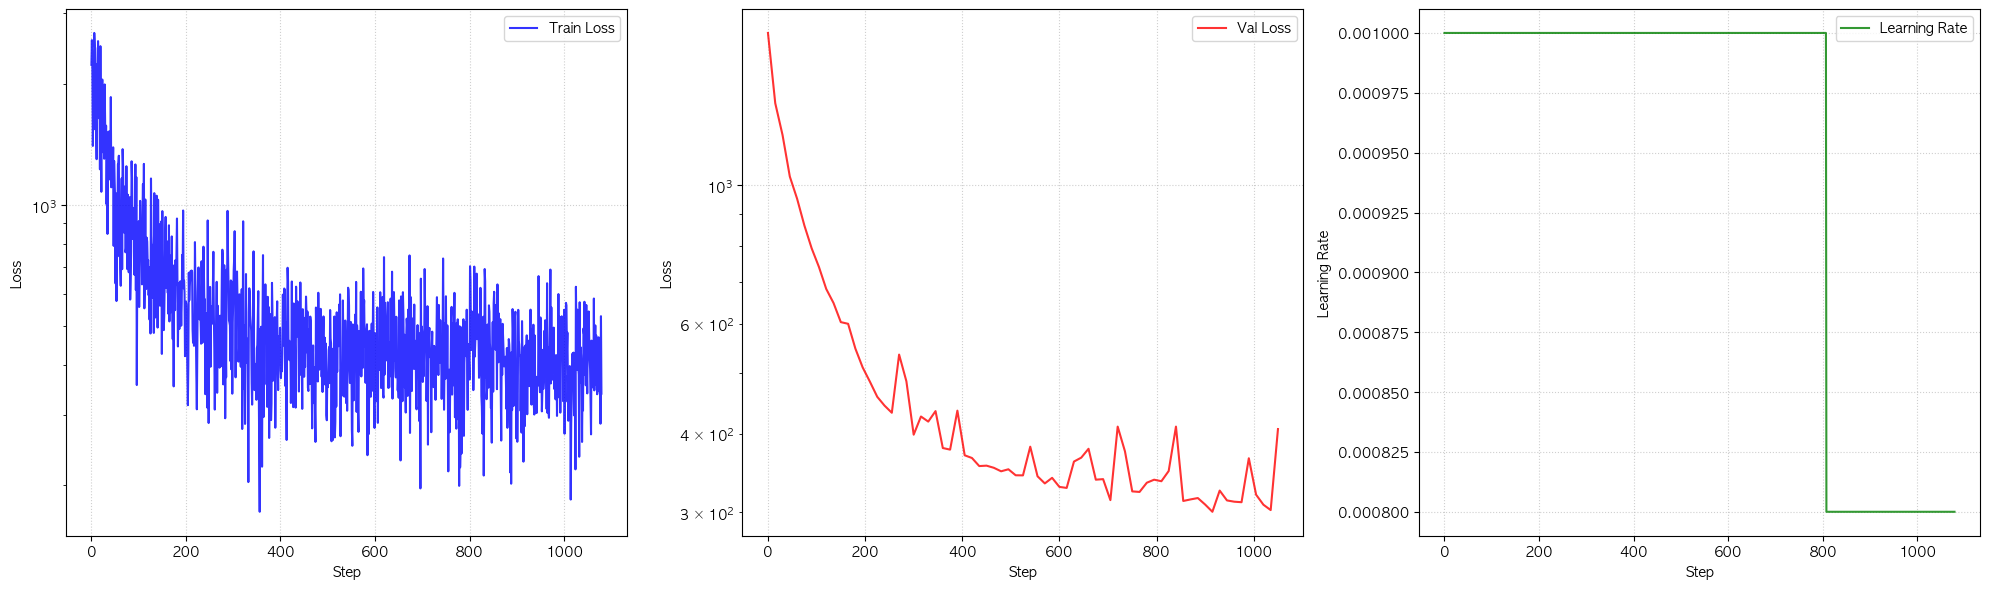

INFO:src.gnn.train.trainer:Step 1080: Train 338.4442, Val 380.5913, Patience 10/10
INFO:src.gnn.train.trainer:Early stopping triggered
INFO:src.gnn.train.trainer:Loss curve saved as results/model_gin_train_default_optim_adam_sch_step/20251012_11_h_47_m/early_stop_loss_curve_gin.png
Training:   1%|          | 1079/202000 [02:28<7:42:20,  7.24it/s]
INFO:src.gnn.train.trainer:Model not loaded from path
INFO:src.gnn.train.trainer:==================================================
INFO:src.gnn.train.trainer:Test results
INFO:src.gnn.train.trainer:Model path: None
INFO:src.gnn.train.trainer:==================================================
INFO:src.gnn.train.trainer:Mean test loss: 376.993430
INFO:src.gnn.train.trainer:MSE: 262232.187500
INFO:src.gnn.train.trainer:RMSE: 512.086121
INFO:src.gnn.train.trainer:MAE: 377.010254
INFO:src.gnn.train.trainer:Correlation: 0.980579
INFO:src.gnn.train.trainer:==================================================
INFO:src.gnn.train.trainer:Model not loaded

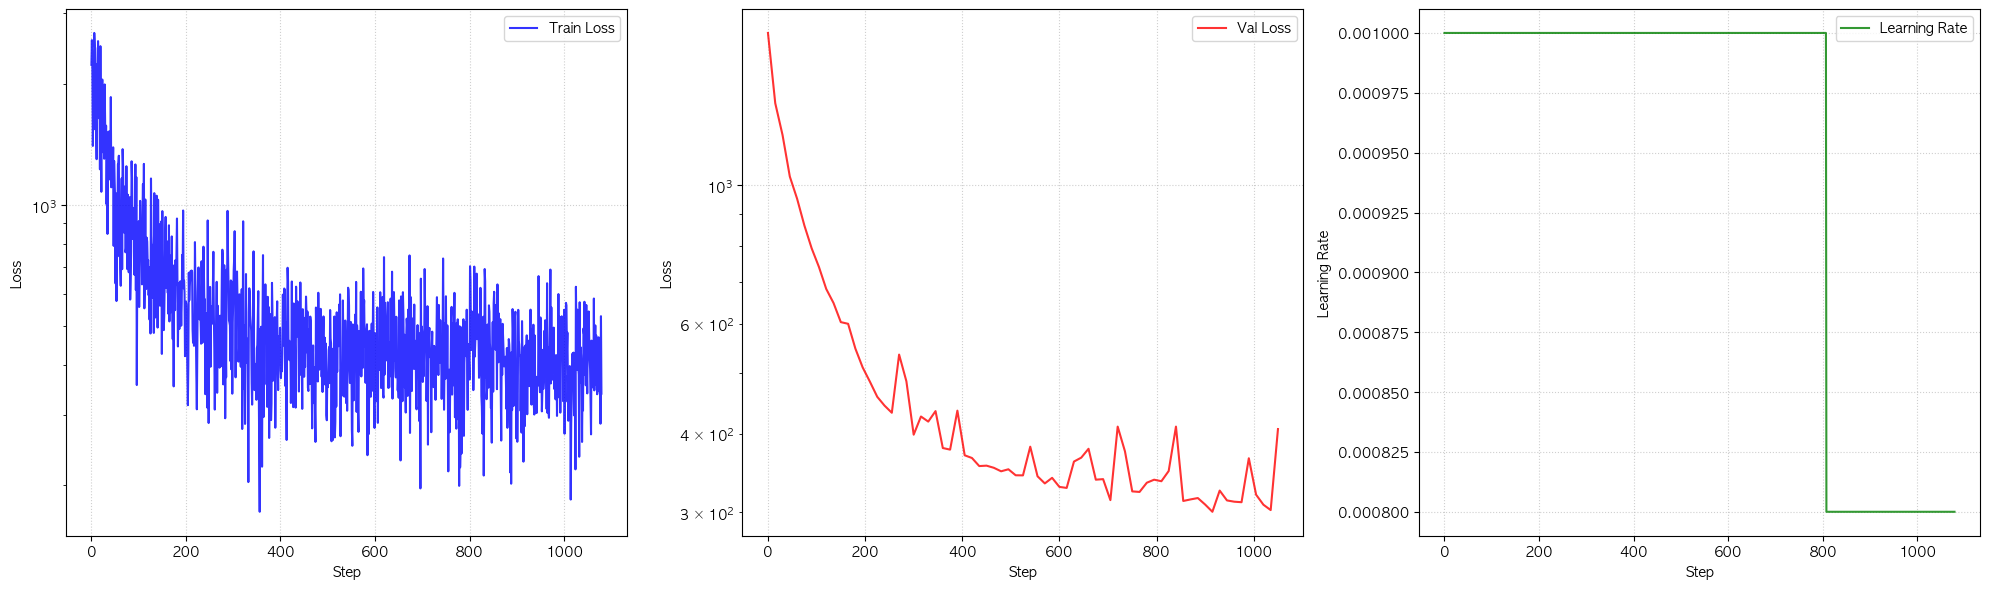

In [34]:
datetime_str = datetime.now().strftime("%Y%m%d_%H_h_%M_m")
device = 'cuda' if torch.cuda.is_available() else 'mps'

model_config_name = 'gin'

model = ModelFactory.create_model(
    model_config_name
)
train_config_name = 'default'
train_config = load_config("train", train_config_name)
optimizer_config_name = 'adam'
scheduler_config_name = 'step'

save_path = f"results/model_{model_config_name}_train_{train_config_name}_optim_{optimizer_config_name}_sch_{scheduler_config_name}/{datetime_str}"
os.makedirs(save_path, exist_ok=True)



trainer = Trainer(
    train_config=train_config,
    model=model,
    optimizer_config_name=optimizer_config_name,
    scheduler_config_name=scheduler_config_name,
    save_path=save_path,
    device=device,
)


trainer.fit(train_loader, valid_loader, epochs=EPOCHS, live_plot_step=10)
results = trainer.test(test_loader)

results = trainer.test(test_loader)

import json
with open(os.path.join(save_path, "results.json"), "w") as f:
    json.dump(results, f)
pd.DataFrame({'targets': results['targets'], 'predictions': results['predictions']}).to_csv(os.path.join(save_path, "predictions.csv"), index=False)


# Baseline 학습

In [35]:
import os
import sys
import torch
import numpy as np
import pandas as pd
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from sklearn.preprocessing import StandardScaler
import xgboost as xgb
import catboost as cb
import matplotlib.pyplot as plt
from torch_geometric.loader import DataLoader



project_root = os.path.abspath(os.path.join(os.getcwd(), '..', '..'))
if project_root not in sys.path:
    sys.path.append(project_root)

from src.gnn.factory.model_factory import ModelFactory

import warnings
warnings.filterwarnings('ignore')
plt.rcParams['font.family'] = 'AppleGothic'


print("Loading dataset...")
train_data = torch.load(folder_path + '/train_datapyg_dataset_scaled_y_sun_coord_true.pt', weights_only=False)
valid_data = torch.load(folder_path + '/valid_datapyg_dataset_scaled_y_sun_coord_true.pt', weights_only=False)
test_data = torch.load(folder_path + '/test_datapyg_dataset_scaled_y_sun_coord_true.pt', weights_only=False)
test_loader = DataLoader(test_data, batch_size=30, shuffle=False)

print(f"Train 데이터 개수: {len(train_data)}")
print(f"Valid 데이터 개수: {len(valid_data)}")
print(f"Test 데이터 개수: {len(test_data)}")


Loading dataset...
Train 데이터 개수: 6458
Valid 데이터 개수: 1387
Test 데이터 개수: 1384


In [36]:
def extract_features(data_list):
    """
    From PyG Data objects, extract features and convert to tabular format
    """
    features = []
    targets = []
    
    for data in data_list:
        # x features (node features)
        x_features = data.x.numpy().flatten()
        
        # global_x features (global features)
        global_features = data.global_x.numpy().flatten()

        combined_features = np.concatenate([x_features, global_features])
        
        features.append(combined_features)
        targets.append(data.y.item())
    
    return np.array(features), np.array(targets)


print("Preprocessing data...")
X_train, y_train = extract_features(train_data)
X_valid, y_valid = extract_features(valid_data)
X_test, y_test = extract_features(test_data)

print(f"Feature shape: {X_train.shape}")
print(f"Target shape: {y_train.shape}")
print(f"Feature names: x_stats + global_features")


Preprocessing data...
Feature shape: (6458, 7403)
Target shape: (6458,)
Feature names: x_stats + global_features


In [37]:
class BaselineModels:
    def __init__(self, need_y_scaling=False):
        self.models = {}
        self.scalers = {}
        self.y_scaler = {}
        self.need_y_scaling = need_y_scaling

    def y_scaling(self, y_train, y_valid):
        if self.need_y_scaling:
            y_scaler = StandardScaler()
            y_train_scaled = y_scaler.fit_transform(y_train.reshape(-1, 1))
            y_valid_scaled = y_scaler.transform(y_valid.reshape(-1, 1))
        else:
            y_scaler = None
            y_train_scaled = y_train
            y_valid_scaled = y_valid
        return y_scaler, y_train_scaled, y_valid_scaled

    def train_linear_regression(self, X_train, y_train, X_valid, y_valid):
        """Linear Regression"""
        print("Linear Regression...")
        scaler = StandardScaler()
        X_train_scaled = scaler.fit_transform(X_train)
        X_valid_scaled = scaler.transform(X_valid)
        
        y_scaler, y_train_scaled, y_valid_scaled = self.y_scaling(y_train, y_valid)

        model = LinearRegression()
        model.fit(X_train_scaled, y_train_scaled)
        
        self.models['linear_regression'] = model
        self.scalers['linear_regression'] = scaler
        self.y_scaler['linear_regression'] = y_scaler
        
        # evaluate
        y_pred = model.predict(X_valid_scaled)
        mse = mean_squared_error(y_valid_scaled, y_pred)
        mae = mean_absolute_error(y_valid_scaled, y_pred)
        r2 = r2_score(y_valid, y_pred)

        # origin scale
        y_pred_origin = y_scaler.inverse_transform(y_pred) if y_scaler else y_pred
        mse_origin = mean_squared_error(y_valid, y_pred_origin)
        mae_origin = mean_absolute_error(y_valid, y_pred_origin)
        r2_origin = r2_score(y_valid, y_pred_origin)
        
        print(f"Linear Regression (Scaled) - MSE: {mse:.4f}, MAE: {mae:.4f}, R²: {r2:.4f}")
        print(f"Linear Regression (Origin) - MSE: {mse_origin:.4f}, MAE: {mae_origin:.4f}, R²: {r2_origin:.4f}")
        return model, scaler, y_scaler
    
    def train_xgboost(self, X_train, y_train, X_valid, y_valid):
        """XGBoost"""
        print("XGBoost...")

        y_scaler, y_train_scaled, y_valid_scaled = self.y_scaling(y_train, y_valid)

        model = xgb.XGBRegressor(
            n_estimators=100,
            max_depth=6,
            learning_rate=0.1,
            random_state=42,
            n_jobs=-1
        )
        model.fit(X_train, y_train_scaled)
        
        self.models['xgboost'] = model
    
        self.y_scaler['xgboost'] = y_scaler
        
        # evaluate
        y_pred = model.predict(X_valid)
        mse = mean_squared_error(y_valid_scaled, y_pred)
        mae = mean_absolute_error(y_valid_scaled, y_pred)
        r2 = r2_score(y_valid, y_pred)

        # origin scale
        y_pred_origin = y_scaler.inverse_transform(y_pred.reshape(-1, 1)) if y_scaler else y_pred
        mse_origin = mean_squared_error(y_valid, y_pred_origin)
        mae_origin = mean_absolute_error(y_valid, y_pred_origin)
        r2_origin = r2_score(y_valid, y_pred_origin)
        
        print(f"Linear Regression (Scaled) - MSE: {mse:.4f}, MAE: {mae:.4f}, R²: {r2:.4f}")
        print(f"Linear Regression (Origin) - MSE: {mse_origin:.4f}, MAE: {mae_origin:.4f}, R²: {r2_origin:.4f}")
        return model, None, y_scaler

    
    def train_catboost(self, X_train, y_train, X_valid, y_valid):
        """CatBoost 모델"""
        print("CatBoost...")
        y_scaler, y_train_scaled, y_valid_scaled = self.y_scaling(y_train, y_valid)

        model = cb.CatBoostRegressor(
            iterations=100,
            depth=6,
            learning_rate=0.1,
            random_seed=42,
            verbose=False
        )
        model.fit(X_train, y_train_scaled)
        
        self.models['catboost'] = model
        self.y_scaler['catboost'] = y_scaler
        
        # evaluate
        y_pred = model.predict(X_valid)
        mse = mean_squared_error(y_valid_scaled, y_pred)
        mae = mean_absolute_error(y_valid_scaled, y_pred)
        r2 = r2_score(y_valid, y_pred)

        # origin scale
        y_pred_origin = y_scaler.inverse_transform(y_pred.reshape(-1, 1)) if y_scaler else y_pred
        mse_origin = mean_squared_error(y_valid, y_pred_origin)
        mae_origin = mean_absolute_error(y_valid, y_pred_origin)
        r2_origin = r2_score(y_valid, y_pred_origin)
        
        print(f"Linear Regression (Scaled) - MSE: {mse:.4f}, MAE: {mae:.4f}, R²: {r2:.4f}")
        print(f"Linear Regression (Origin) - MSE: {mse_origin:.4f}, MAE: {mae_origin:.4f}, R²: {r2_origin:.4f}")
        return model, None, y_scaler


    def evaluate_metrics(self, y_true, y_pred, prefix=''):
        # 1. MSE (Mean Squared Error)
        mse = mean_squared_error(y_true, y_pred)
        # 2. MAE (Mean Absolute Error)
        mae = mean_absolute_error(y_true, y_pred)
        # 3. RMSE (Root Mean Squared Error)
        rmse = np.sqrt(mse).item()
        # 4. R² (Coefficient of Determination)
        r2 = r2_score(y_true, y_pred)
        
        results = {
            f'{prefix}MSE': mse,
            f'{prefix}MAE': mae,
            f'{prefix}RMSE': rmse,
            f'{prefix}R²': r2,
        }
        return results
        

    def evaluate_all(self, X_test, y_test, save_path):
        import os
        os.makedirs(save_path, exist_ok=True)
        results = {}
        
        for name, model in self.models.items():
            if name == 'mlp':
                scaler = self.scalers[name]
                X_test_scaled = scaler.transform(X_test)
                X_test_tensor = torch.FloatTensor(X_test_scaled)
                
                model.eval()
                with torch.no_grad():
                    y_pred = model(X_test_tensor).numpy()
            elif name == 'linear_regression':
                scaler = self.scalers[name]
                X_test_scaled = scaler.transform(X_test)
                y_test_scaled = self.y_scaler[name].transform(y_test.reshape(-1, 1)) if self.y_scaler[name] else y_test
                y_pred = model.predict(X_test_scaled)
            else:
                y_test_scaled = self.y_scaler[name].transform(y_test.reshape(-1, 1)) if self.y_scaler[name] else y_test
                y_pred = model.predict(X_test)

            # origin scale
            y_pred_origin = self.y_scaler[name].inverse_transform(y_pred.reshape(-1, 1)) if self.y_scaler[name] else y_pred

            origin_metrics = self.evaluate_metrics(y_test, y_pred_origin, prefix='Origin_')
            scaled_metrics = self.evaluate_metrics(y_test_scaled, y_pred, prefix='Scaled_')

            all_metrics = {**origin_metrics, **scaled_metrics}
            results[name] = all_metrics

            print(f"""{name} -
            Origin_MSE: {all_metrics['Origin_MSE']:.4f}, Origin_MAE: {all_metrics['Origin_MAE']:.4f}, Origin_RMSE: {all_metrics['Origin_RMSE']:.4f}, Origin_R²: {all_metrics['Origin_R²']:.4f},
            Scaled_MSE: {all_metrics['Scaled_MSE']:.4f}, Scaled_MAE: {all_metrics['Scaled_MAE']:.4f}, Scaled_RMSE: {all_metrics['Scaled_RMSE']:.4f}, Scaled_R²: {all_metrics['Scaled_R²']:.4f}""")

            pd.DataFrame({'targets': y_test.tolist(), 'predictions': y_pred_origin.tolist()}).to_csv(os.path.join(save_path, f"scaled_{self.need_y_scaling}_{name}_predictions.csv"), index=False)

        return results


In [38]:
def best_model_predict(model, loader, device):
    model.eval()
    model.to(device)
    y_pred = []
    y_true = []
    with torch.no_grad():
        for data in loader:
            data = data.to(device)
            out = model(data).view(-1)
            y_pred.extend(out.cpu().numpy().tolist())
            y_true.extend(data.y.cpu().numpy().reshape(-1).tolist())

    return y_pred, y_true

In [39]:
baseline_models = BaselineModels(need_y_scaling=False)
# 1. Linear Regression
baseline_models.train_linear_regression(X_train, y_train, X_valid, y_valid)

# 2. XGBoost
baseline_models.train_xgboost(X_train, y_train, X_valid, y_valid)

# 3. CatBoost
baseline_models.train_catboost(X_train, y_train, X_valid, y_valid)

print("=" * 50)
print("All models trained!")
print("=" * 50)


results = baseline_models.evaluate_all(X_test, y_test, save_path="baseline_results")


# 4. Best Model
device = 'gpu' if torch.cuda.is_available() else 'mps'
best_model = ModelFactory.create_model(
    'gcn'
)
best_model.load_state_dict(torch.load('results/best_model_gcn.pt'))
best_model_predictions, best_model_targets = best_model_predict(best_model, test_loader, device)
best_model_scores = baseline_models.evaluate_metrics(best_model_targets, best_model_predictions, 'Origin_')
best_model_results = {'best_model': best_model_scores}
best_model_results = pd.DataFrame({'best_model': best_model_scores})

all_results = pd.DataFrame(results)
all_results = pd.concat([all_results, best_model_results], axis=1).T
all_results.head()


Linear Regression...
Linear Regression (Scaled) - MSE: 659033.8166, MAE: 626.5194, R²: 0.8260
Linear Regression (Origin) - MSE: 659033.8166, MAE: 626.5194, R²: 0.8260
XGBoost...
Linear Regression (Scaled) - MSE: 37736.4056, MAE: 129.9576, R²: 0.9900
Linear Regression (Origin) - MSE: 37736.4056, MAE: 129.9576, R²: 0.9900
CatBoost...


INFO:src.gnn.utils.config_utils:CONFIG_DIR: /Users/maeng.k/workspace/RealTimeFacadeControl-GNN-RL/src/gnn/utils/../config
INFO:src.gnn.utils.config_utils:Loading config: model gcn
INFO:src.gnn.factory.model_factory:Model config: {'model_type': 'gcn', 'description': 'Graph Convolutional Network - A Graph Convolutional Network model that uses graph convolution to learn graph structure.', 'model_config': {'in_channels': 4, 'hidden_channels': 16, 'global_dim': 7, 'out_dim': 1, 'num_layers': 2, 'use_edge_attr': False, 'use_global_features': True, 'coord_embed_method': 'spherical', 'pooling_method': 'mean', 'activation_function': 'relu', 'dropout': 0.1, 'edge_dim': 2, 'edge_embedding_dim': 16, 'user_global_coord_embedder': False, 'special_config': {'normalize': True, 'add_self_loops': True, 'bias': True}}}


Linear Regression (Scaled) - MSE: 77230.7939, MAE: 189.3462, R²: 0.9796
Linear Regression (Origin) - MSE: 77230.7939, MAE: 189.3462, R²: 0.9796
All models trained!
linear_regression -
            Origin_MSE: 592774.4440, Origin_MAE: 590.5117, Origin_RMSE: 769.9185, Origin_R²: 0.8459,
            Scaled_MSE: 592774.4440, Scaled_MAE: 590.5117, Scaled_RMSE: 769.9185, Scaled_R²: 0.8459
xgboost -
            Origin_MSE: 33946.2549, Origin_MAE: 126.4400, Origin_RMSE: 184.2451, Origin_R²: 0.9912,
            Scaled_MSE: 33946.2549, Scaled_MAE: 126.4400, Scaled_RMSE: 184.2451, Scaled_R²: 0.9912
catboost -
            Origin_MSE: 70963.0251, Origin_MAE: 183.1603, Origin_RMSE: 266.3889, Origin_R²: 0.9816,
            Scaled_MSE: 70963.0251, Scaled_MAE: 183.1603, Scaled_RMSE: 266.3889, Scaled_R²: 0.9816


FileNotFoundError: [Errno 2] No such file or directory: 'results/best_model_gcn.pt'

# Baseline - Visualization

In [ ]:
# 시각화 코드
# 1. 모델 성능 비교 시각화
plt.figure(figsize=(15, 10))

# R² 점수 비교
plt.subplot(2, 2, 1)
r2_scores = all_results['Origin_R²'].sort_values(ascending=True)
plt.barh(range(len(r2_scores)), r2_scores.values)
plt.yticks(range(len(r2_scores)), r2_scores.index)
plt.xlabel('R² Score')
plt.title('모델별 R² 성능 비교')
plt.grid(True, alpha=0.3)

# MSE 점수 비교
plt.subplot(2, 2, 2)
mse_scores = all_results['Origin_MSE'].sort_values(ascending=False)
plt.barh(range(len(mse_scores)), mse_scores.values)
plt.yticks(range(len(mse_scores)), mse_scores.index)
plt.xlabel('MSE')
plt.title('모델별 MSE 성능 비교')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# MAE 점수 비교
plt.subplot(2, 2, 1)
mae_scores = all_results['Origin_MAE'].sort_values(ascending=True)
plt.barh(range(len(mae_scores)), mae_scores.values)
plt.yticks(range(len(mae_scores)), mae_scores.index)
plt.xlabel('MAE')
plt.title('모델별 MAE 성능 비교')
plt.grid(True, alpha=0.3)


# 2. 예측 vs 실제 값 시각화 (최고 성능 모델)
plt.figure(figsize=(12, 5))


def predict(model_name, baseline_class, X):
    if model_name == 'linear_regression':
        scaler = baseline_class.scalers[model_name]
        X_scaled = scaler.transform(X)
    else:
        X_scaled = X_test
    model = baseline_class.models[model_name]
    y_pred = model.predict(X_scaled)

    if baseline_class.y_scaler[model_name] is not None:
        return baseline_class.y_scaler[model_name].inverse_transform(y_pred.reshape(-1, 1))
    else:
        return y_pred




model_names = ['linear_regression', 'xgboost', 'catboost', 'best_model']

for model_name in model_names:
    if model_name == 'best_model':
        y_pred = best_model_predictions
        _y_test = np.array(best_model_targets)
    else:
        y_pred = predict(model_name, baseline_models, X_test).reshape(-1)
        _y_test = np.array(y_test)
    plt.subplot(1, 2, 1)
    plt.scatter(_y_test, y_pred, alpha=0.6)
    # plt.plot([_y_test.min(), _y_test.max()], [_y_test.min(), _y_test.max()], 'r--', lw=2)
    plt.plot([_y_test.min(), _y_test.max()], [_y_test.min(), _y_test.max()], 'r--', lw=2)
    plt.xlabel('실제 값')
    plt.ylabel('예측 값')
    plt.title(f'{model_name} - 예측 vs 실제 값')
    plt.grid(True, alpha=0.3)

    # 잔차 플롯
    plt.subplot(1, 2, 2)
    residuals = _y_test - y_pred
    plt.scatter(y_pred, residuals, alpha=0.6)
    plt.axhline(y=0, color='r', linestyle='--')
    plt.xlabel('예측 값')
    plt.ylabel('잔차')
    plt.title(f'{model_name} - 잔차 플롯')
    plt.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()




# RL 학습

## 데이터 준비

In [55]:
# import pkgs

import glob
import os
import torch
import pandas as pd
import numpy as np

from scaler.feature_scaler import GraphTargetScaler
import utils.pyg_dataset as pyg_dataset
from utils.utils import train_valid_test_split_indices

import warnings
warnings.filterwarnings('ignore')

# constant
EPW_FILE_PATH = folder_path + "/EPW_Mar-Nov_SolarData_WithTemp_v2.csv"
SUN_NODE_ID = 0
PITCH_NODE_ID = 1
START_NODE_ID = 2
END_NODE_ID = 1850


In [41]:
folder_path = "./data"
node_csv_files = glob.glob(os.path.join(folder_path, "**", "*node*.csv"), recursive=True)
edge_csv_files = glob.glob(os.path.join(folder_path, "**", "*edge*.csv"), recursive=True)
node_csv_files.sort()
edge_csv_files.sort()

# File Sanity Check
for node_file in node_csv_files[:]:
    expected_edge_file = node_file.replace('node', 'edge')

    if expected_edge_file not in edge_csv_files:
        print(f"[Warning] Corresponding edge file not found for: {node_file}")
        print(f"          '{node_file}' will be removed from the node list.")
        node_csv_files.remove(node_file)

for edge_file in edge_csv_files[:]:
    expected_node_file = edge_file.replace('edge', 'node')
    if expected_node_file not in node_csv_files:
        print(f"[Warning] Corresponding node file not found for: {edge_file}")
        print(f"          '{edge_file}' will be removed from the edge list.")

        # edge_csv_files 리스트에서 해당 파일을 제거합니다.
        edge_csv_files.remove(edge_file)


print("\n--- Sanity Check Complete ---")
print("Updated node_csv_files:", len(node_csv_files))
print("Updated edge_csv_files:", len(edge_csv_files))



[Warning] Corresponding edge file not found for: ./data/0_close_0to90/0_close_0to90_Output_1374-42-86-0.65-10-25-18_case1374_node.csv
          './data/0_close_0to90/0_close_0to90_Output_1374-42-86-0.65-10-25-18_case1374_node.csv' will be removed from the node list.

--- Sanity Check Complete ---
Updated node_csv_files: 9378
Updated edge_csv_files: 9378


In [53]:
from utils.utils import train_valid_test_split_indices

train_idx, valid_idx, test_idx = train_valid_test_split_indices(
    n_samples=len(node_csv_files),
    train_size=0.90,
    valid_size=0.001,
    test_size=0.099,
    random_state=42,
)

train_node_csv_files = [node_csv_files[i] for i in train_idx]
train_edge_csv_files = [edge_csv_files[i] for i in train_idx]

test_node_csv_files = [node_csv_files[i] for i in test_idx]
test_edge_csv_files = [edge_csv_files[i] for i in test_idx]

INFO:utils.utils:train_size: 0.9, valid_size: 0.001, test_size: 0.099
INFO:utils.utils:train_idx: 8440, valid_idx: 9, test_idx: 929


In [56]:
train_datapyg_dataset, train_fail_file_paths = pyg_dataset.create_multi_graph_dataset(
    node_file_paths=train_node_csv_files,
    edge_file_paths=train_edge_csv_files,
    epw_file_path=EPW_FILE_PATH,
    target_columns=['운동장_태양복사열'],
    start_node_id=START_NODE_ID,
    end_node_id=END_NODE_ID,
    sun_node_id=SUN_NODE_ID,
    pitch_node_id=PITCH_NODE_ID,
    multi_task=False,
    use_node_coord=True,
    use_sun_coord=True,
    target_scaler=target_scaler,
)

test_datapyg_dataset, test_fail_file_paths = pyg_dataset.create_multi_graph_dataset(
    node_file_paths=test_node_csv_files,
    edge_file_paths=test_edge_csv_files,
    epw_file_path=EPW_FILE_PATH,
    target_columns=['운동장_태양복사열'],
    start_node_id=START_NODE_ID,
    end_node_id=END_NODE_ID,
    sun_node_id=SUN_NODE_ID,
    pitch_node_id=PITCH_NODE_ID,
    multi_task=False,
    use_node_coord=True,
    use_sun_coord=False,
    target_scaler=target_scaler,
)

print(f"Train fail file paths: {len(train_fail_file_paths)}")
print(f"Test fail file paths: {len(test_fail_file_paths)}")

print(len(train_datapyg_dataset))
print(len(test_datapyg_dataset))


torch.save(train_datapyg_dataset, folder_path + '/datapyg_dataset_rl.pt' )
torch.save(train_datapyg_dataset, folder_path + '/datapyg_dataset_rl_test.pt' )


  0%|          | 4/8440 [00:00<04:26, 31.62it/s]WARNING:utils.pandas_utils:Sun to pitchPt distance is 0 ---> Sun Set off ---> file will be passed
INFO:utils.pyg_dataset:Fail files: ./data/3_open_90to45/3_open_90to45_Output_1517-42-86-0.65-11-19-18_case1517_node.csv
  1%|          | 85/8440 [00:03<04:29, 31.01it/s]WARNING:utils.pandas_utils:Sun to pitchPt distance is 0 ---> Sun Set off ---> file will be passed
INFO:utils.pyg_dataset:Fail files: ./data/1_open_90to0/1_open_90to0_Output_1462-42-86-0.65-11-9-18_case1462_node.csv
  2%|▏         | 161/8440 [00:05<07:09, 19.27it/s]WARNING:utils.pandas_utils:Sun to pitchPt distance is 0 ---> Sun Set off ---> file will be passed
INFO:utils.pyg_dataset:Fail files: ./data/4_close_all_0/4_close_all_0_Output_1352-42-86-0.65-10-21-18_case1352_node.csv
  2%|▏         | 185/8440 [00:06<04:21, 31.62it/s]WARNING:utils.pandas_utils:Sun to pitchPt distance is 0 ---> Sun Set off ---> file will be passed
INFO:utils.pyg_dataset:Fail files: ./data/2_close_45to

Train fail file paths: 139
Test fail file paths: 10
8301
919


## GNN 모델 준비

In [ ]:
from omegaconf import OmegaConf
import torch
import pandas as pd
import json

from src.gnn.model.model import GraphRegressorV2

model_ckpt_paths = [
    "/Users/maeng.k/workspace/RealTimeFacadeControl-GNN-RL/output/gnn/crowd/best_model_gin.pt",
    "/Users/maeng.k/workspace/RealTimeFacadeControl-GNN-RL/output/gnn/field/best_model_gin.pt",
]
config_paths = [
    "/Users/maeng.k/workspace/RealTimeFacadeControl-GNN-RL/output/gnn/crowd/gin_3_new_5.yaml",
    "/Users/maeng.k/workspace/RealTimeFacadeControl-GNN-RL/output/gnn/field/gin_3_new_5.yaml",
]

for model_ckpt_path, config_path in zip(model_ckpt_paths, config_paths):
    config = OmegaConf.load(config_path)

    model = GraphRegressorV2(
        gnn_type="gin",
        config=config.model_config,
    )
    model.load_state_dict(torch.load(model_ckpt_path, map_location=torch.device("cpu")))
    model.eval()
    torch.save(model, model_ckpt_path.replace(".pt", "_with_class.pt"))
    print(f"Saved {model_ckpt_path} as {model_ckpt_path.replace('.pt', '_with_class.pt')}")

## 학습

In [ ]:
from src.rl.src.train import main

main(config_path="src/rl/configs/default.yaml", run_name="run_1", device="auto")